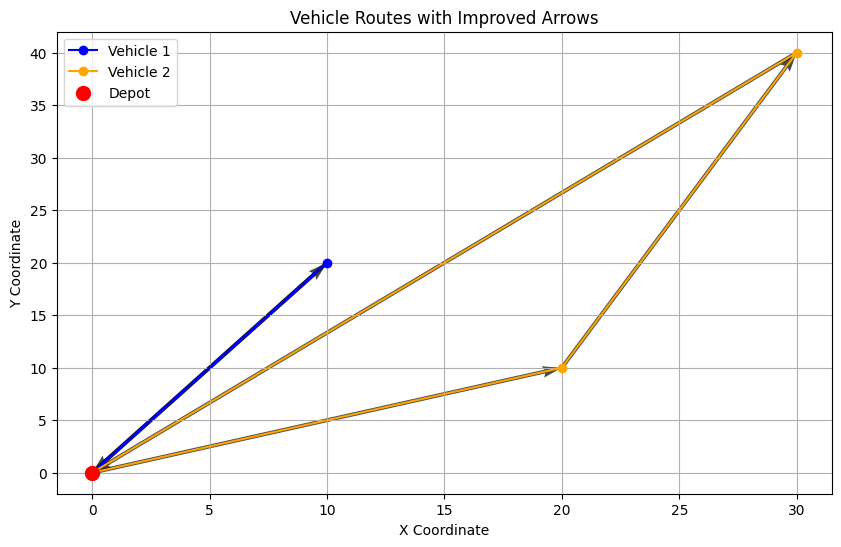

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Example coordinates for the locations (replace with your actual coordinates)
location_coordinates = [
    (0, 0),   # Depot
    (10, 20), # Location 1
    (20, 10), # Location 2
    (30, 40), # Location 3
    (40, 30)  # Location 4
]

def plot_routes_with_quiver(routes, location_coordinates):
    plt.figure(figsize=(10, 6))

    colors = ['blue', 'orange', 'green', 'purple', 'brown']  # Colors for vehicles
    
    # Plot each vehicle's route
    for vehicle_id, route in enumerate(routes):
        x_coords = []
        y_coords = []
        
        # Extract coordinates from the route
        for stop in route:
            loc_id = stop[0]  # Assuming the first element of the stop is the location ID
            x, y = location_coordinates[loc_id]
            x_coords.append(x)
            y_coords.append(y)
        
        # Add depot at start and end (if needed)
        depot_x, depot_y = location_coordinates[0]
        x_coords = [depot_x] + x_coords + [depot_x]
        y_coords = [depot_y] + y_coords + [depot_y]

        # Plot the route with unique color
        plt.plot(x_coords, y_coords, marker='o', color=colors[vehicle_id % len(colors)], label=f'Vehicle {vehicle_id + 1}')

        # Compute arrow directions
        U = np.diff(x_coords)  # X differences
        V = np.diff(y_coords)  # Y differences
        X_mid = x_coords[:-1]  # Start positions
        Y_mid = y_coords[:-1]

        # Use quiver for better arrows
        plt.quiver(X_mid, Y_mid, U, V, angles='xy', scale_units='xy', scale=1, color='black', alpha=0.7, width=0.005)

    # Plot depot
    plt.scatter(depot_x, depot_y, color='red', label='Depot', s=100, zorder=5)

    # Add labels and legend
    plt.title('Vehicle Routes with Improved Arrows')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example routes from your function output (replace with actual routes)
example_routes = [
    [(0, 0, 10, 5, 100), (1, 10, 20, 3, 200)],
    [(0, 0, 10, 5, 100), (2, 20, 30, 4, 150), (3, 30, 40, 2, 250)]
]

plot_routes_with_quiver(example_routes, location_coordinates)
